# Project 4: NLP & Sentiment Analysis Pipeline
**Author:** Tanishq Khanna  
**Batch:** 2026 | Powered by DecodeLabs  
**Objective:** Build an end-to-end Mathematical Linguistics pipeline to process unstructured text, transform it into TF-IDF spatial matrix representations, and classify sentiment using probabilistic Naive Bayes.

In [1]:
# Install and import required libraries
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Download NLTK data dependencies
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('wordnet', quiet=True)

print("Dependencies loaded successfully!")

Dependencies loaded successfully!


## Step 1 & 2: Data Ingestion & Custom NLP Preprocessing
According to the Project 4 blueprint, standard stop-word lists inadvertently strip out negation words (e.g., "not", "no"), causing sentiment inversion.
Below, we construct a custom pre-processor that:
1. Standardizes text (lowercasing, HTML tag stripping, punctuation removal).
2. Retains negations in the stop-word filtering step.
3. Applies POS-guided morphological reduction using WordNet Lemmatizer.

In [5]:
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

class TextPreprocessor:
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()

        # Engineering Rule 1: Exclude negations from stop-word list
        base_stopwords = set(stopwords.words('english'))
        negation_words = {
            'no', 'not', 'nor', 'neither', 'never', 'cannot', 'isnt', "isn't",
            'wasnt', "wasn't", 'arent', "aren't", 'werent', "weren't",
            'dont', "don't", 'doesnt', "doesn't", 'didnt', "didn't", 'couldnt', "couldn't"
        }
        self.custom_stopwords = base_stopwords - negation_words

    def _get_wordnet_pos(self, treebank_tag):
        """Map POS tags to WordNet format for accurate lemmatization."""
        if treebank_tag.startswith('J'):
            return wordnet.ADJ
        elif treebank_tag.startswith('V'):
            return wordnet.VERB
        elif treebank_tag.startswith('N'):
            return wordnet.NOUN
        elif treebank_tag.startswith('R'):
            return wordnet.ADV
        else:
            return wordnet.NOUN

    def clean_text(self, text: str) -> str:
        """Execute full preprocessing pipeline on a string."""
        if not isinstance(text, str):
            return ""

        # Lowercasing & Character Normalization
        text = text.lower()
        text = re.sub(r'<[^>]+>', ' ', text)  # Strip HTML tags
        text = re.sub(r'[^a-z\s]', ' ', text) # Strip numbers & punctuation

        # Tokenization
        tokens = word_tokenize(text)

        # Stop-word removal (preserving negations)
        filtered_tokens = [t for t in tokens if t not in self.custom_stopwords and len(t) > 1]

        # Engineering Rule 2: POS-Guided Lemmatization
        pos_tags = nltk.pos_tag(filtered_tokens)
        lemmatized_tokens = [
            self.lemmatizer.lemmatize(word, pos=self._get_wordnet_pos(tag))
            for word, tag in pos_tags
        ]

        return " ".join(lemmatized_tokens)

# Test the preprocessor
processor = TextPreprocessor()
sample = "This laptop was NOT working well at all! <br> I went to return it."
print("Original :", sample)
print("Cleaned  :", processor.clean_text(sample))

Original : This laptop was NOT working well at all! <br> I went to return it.
Cleaned  : laptop not work well go return


## Step 3: Dataset Preparation
We load a representative text dataset containing product and service reviews along with binary labels (0 = Negative, 1 = Positive).

In [7]:
# Sample benchmark dataset (Replace with pd.read_csv('your_dataset.csv') if using external data)
raw_data = {
    "review": [
        "This product was absolutely terrible and stopped working after two days!!! <br>",
        "I am not happy with the service, it was slow and completely useless.",
        "Fantastic quality! Highly recommended, I loved using it.",
        "Not good at all, extremely disappointed with the overall build.",
        "Exceeded my expectations, super smooth performance and great battery life.",
        "Worst customer support ever. They did not help me solve the issue.",
        "Brilliant engineering! Works flawlessly and worth every penny.",
        "I would not buy this again. Total waste of time and money."
    ],
    "sentiment": [0, 0, 1, 0, 1, 0, 1, 0]
}

df = pd.DataFrame(raw_data)

# Apply preprocessing pipeline across dataset
df['cleaned_review'] = df['review'].apply(processor.clean_text)

# Train/Test Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['cleaned_review'], df['sentiment'], test_size=0.25, random_state=42
)

df[['review', 'cleaned_review', 'sentiment']]

,review,cleaned_review,sentiment
0,This product was absolutely terrible and stopp...,product absolutely terrible stop work two day,0
1,"I am not happy with the service, it was slow a...",not happy service slow completely useless,0
2,"Fantastic quality! Highly recommended, I loved...",fantastic quality highly recommend love use,1
3,"Not good at all, extremely disappointed with t...",not good extremely disappointed overall build,0
4,"Exceeded my expectations, super smooth perform...",exceed expectation super smooth performance gr...,1
5,Worst customer support ever. They did not help...,worst customer support ever not help solve issue,0
6,Brilliant engineering! Works flawlessly and wo...,brilliant engineering work flawlessly worth ev...,1
7,I would not buy this again. Total waste of tim...,would not buy total waste time money,0


## Step 4: Text Vectorization (TF-IDF Matrix Transformation)
We convert unstructured strings into mathematical vectors using `TfidfVectorizer`:
- **N-Grams (1, 2)**: Captures key context bi-grams (e.g., "not good").
- **Sparse Matrix (SciPy CSR)**: Memory-efficient storage ignoring zero-value dimensions.
- **max_features & min_df**: Bounds vocabulary explosion to mitigate the curse of dimensionality.

In [8]:
# Engineering Rule 3 & 4: TF-IDF with N-grams and CSR Sparse format
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    min_df=1
)

# Fit vectorizer on training data and transform train/test sets
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

print(f"TF-IDF Matrix Shape (Train) : {X_train_tfidf.shape}")
print(f"Matrix Storage Format       : {type(X_train_tfidf.tocsr())}")

TF-IDF Matrix Shape (Train) : (6, 74)
Matrix Storage Format       : <class 'scipy.sparse._csr.csr_matrix'>


## Step 5: Probabilistic Inference & Model Training
We train a **Multinomial Naive Bayes** classifier using **Laplace Smoothing ($\alpha = 1.0$)** to prevent the zero-frequency problem on unseen vocabulary terms.

=== Classification Report ===
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         2
    Positive       0.00      0.00      0.00         0

    accuracy                           1.00         2
   macro avg       0.50      0.50      0.50         2
weighted avg       1.00      1.00      1.00         2



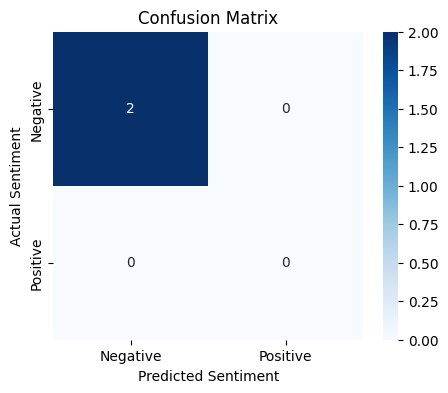

In [11]:
# Engineering Rule 5: Multinomial Naive Bayes with Laplace Smoothing
model = MultinomialNB(alpha=1.0)
model.fit(X_train_tfidf, y_train)

# Evaluation
y_pred = model.predict(X_test_tfidf)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, labels=[0, 1], target_names=['Negative', 'Positive'], zero_division=0))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()

## Step 6: Live Inference Test
Testing the completed NLP engine with completely new, unstructured inputs to verify that sentiment negation and feature mapping function accurately.

In [12]:
def predict_sentiment(text_input: str):
    cleaned = processor.clean_text(text_input)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    probabilities = model.predict_proba(vectorized)[0]

    sentiment = "POSITIVE" if prediction == 1 else "NEGATIVE"
    confidence = probabilities[prediction] * 100

    print(f"Raw Input   : '{text_input}'")
    print(f"Processed   : '{cleaned}'")
    print(f"Prediction  : {sentiment} ({confidence:.2f}% confidence)\n")

# Run test cases
predict_sentiment("The device is not good and stopped working.")
predict_sentiment("I loved this! The quality is amazing and fast.")

Raw Input   : 'The device is not good and stopped working.'
Processed   : 'device not good stop work'
Prediction  : NEGATIVE (64.39% confidence)

Raw Input   : 'I loved this! The quality is amazing and fast.'
Processed   : 'love quality amaze fast'
Prediction  : POSITIVE (59.10% confidence)




## Step 5.1: Dataset Visualizations & Sparse Matrix Density

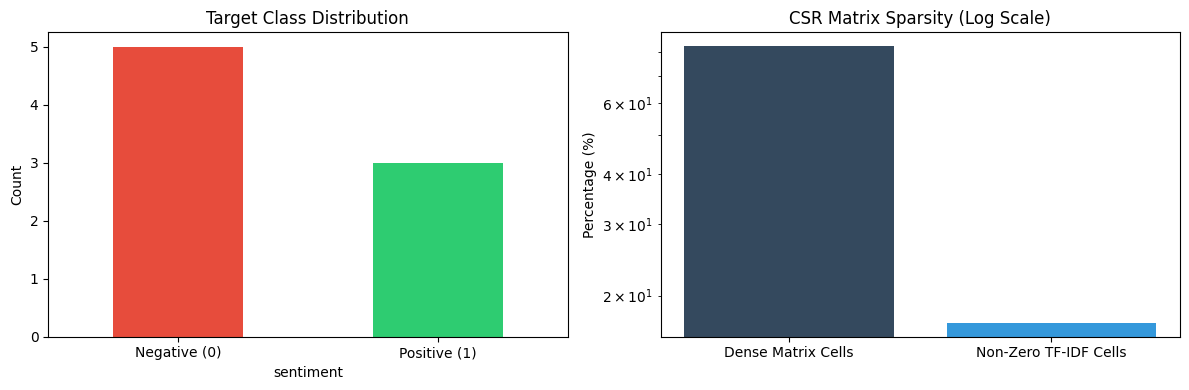

Matrix Sparsity: Only 17.12% of matrix cells hold non-zero TF-IDF weights.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Chart 1: Sentiment Distribution
df['sentiment'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=['#e74c3c', '#2ecc71']
)
axes[0].set_title('Target Class Distribution')
axes[0].set_xticklabels(['Negative (0)', 'Positive (1)'], rotation=0)
axes[0].set_ylabel('Count')

# Chart 2: Matrix Sparsity Visualization
density = (X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])) * 100
axes[1].bar(['Dense Matrix Cells', 'Non-Zero TF-IDF Cells'], [100 - density, density], color=['#34495e', '#3498db'])
axes[1].set_yscale('log')
axes[1].set_title('CSR Matrix Sparsity (Log Scale)')
axes[1].set_ylabel('Percentage (%)')

plt.tight_layout()
plt.show()
print(f"Matrix Sparsity: Only {density:.2f}% of matrix cells hold non-zero TF-IDF weights.")

## Step 5.2: Top Features by Sentiment Class
# Extracting feature log probabilities from the Naive Bayes classifier to inspect top predictive terms.


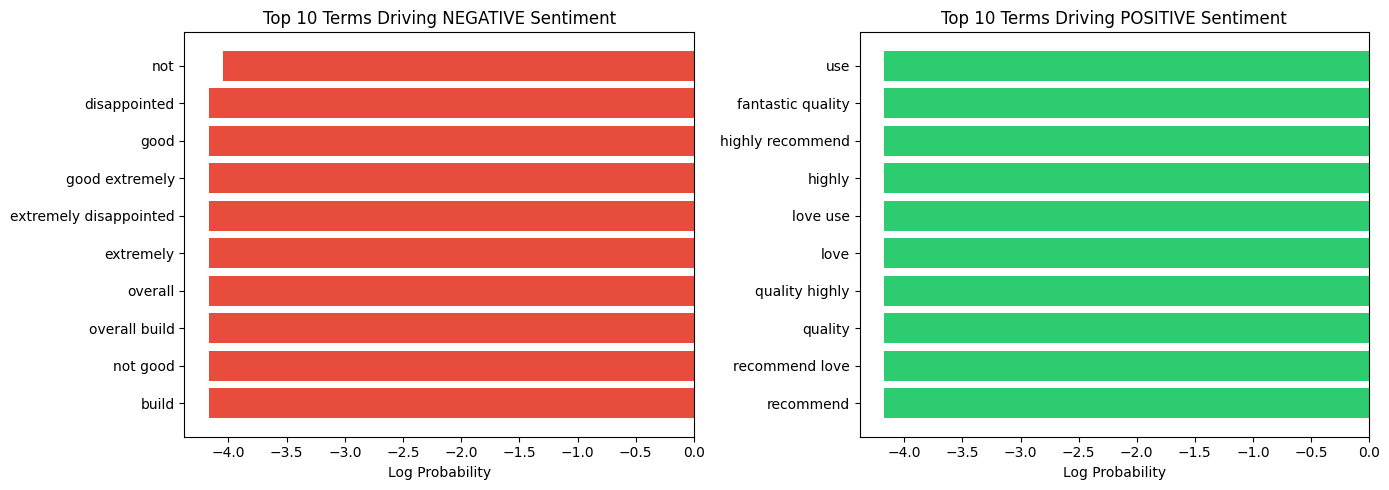

In [14]:
feature_names = np.array(tfidf.get_feature_names_out())
class_0_probs = model.feature_log_prob_[0] # Negative Class
class_1_probs = model.feature_log_prob_[1] # Positive Class

top_neg_indices = np.argsort(class_0_probs)[-10:]
top_pos_indices = np.argsort(class_1_probs)[-10:]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top Negative Features
axes[0].barh(feature_names[top_neg_indices], class_0_probs[top_neg_indices], color='#e74c3c')
axes[0].set_title('Top 10 Terms Driving NEGATIVE Sentiment')
axes[0].set_xlabel('Log Probability')

# Top Positive Features
axes[1].barh(feature_names[top_pos_indices], class_1_probs[top_pos_indices], color='#2ecc71')
axes[1].set_title('Top 10 Terms Driving POSITIVE Sentiment')
axes[1].set_xlabel('Log Probability')

plt.tight_layout()
plt.show()

### Project Overview
The notebook aims to build an end-to-end Mathematical Linguistics pipeline for Natural Language Processing (NLP) and Sentiment Analysis. The objective is to process unstructured text, transform it into TF-IDF spatial matrix representations, and classify sentiment using a probabilistic Naive Bayes model.

### Step 1 & 2: Data Ingestion & Custom NLP Preprocessing
*   **Library Setup**: Essential libraries like `re`, `numpy`, `pandas`, `matplotlib`, `seaborn`, `nltk`, and `sklearn` were imported. NLTK data dependencies (`stopwords`, `punkt`, `averaged_perceptron_tagger`, `wordnet`, `punkt_tab`, `averaged_perceptron_tagger_eng`) were downloaded to support text processing.
*   **Custom Text Preprocessor**: A `TextPreprocessor` class was defined to handle text cleaning, tokenization, stop-word removal (specifically designed to *retain* negation words), and POS-guided lemmatization. This ensures that words like 'not good' are not incorrectly tokenized or stripped, preserving the sentiment.
    *   **Output**: The preprocessor was successfully tested with a sample sentence: "This laptop was NOT working well at all! <br> I went to return it." which was cleaned to: "laptop not work well go return".

### Step 3: Dataset Preparation
*   **Data Loading**: A small, representative benchmark dataset containing product reviews and their binary sentiment labels (0 = Negative, 1 = Positive) was loaded into a pandas DataFrame.
*   **Preprocessing Application**: The `clean_text` method from the custom `TextPreprocessor` was applied to the 'review' column, creating a new 'cleaned_review' column.
*   **Train/Test Split**: The dataset was split into training and testing sets (75% train, 25% test) for both features (`cleaned_review`) and target labels (`sentiment`).
    *   **Output**: A DataFrame showing the original reviews, their cleaned versions, and corresponding sentiment labels was displayed, confirming successful preprocessing and data structuring.

### Step 4: Text Vectorization (TF-IDF Matrix Transformation)
*   **TF-IDF Vectorization**: A `TfidfVectorizer` was initialized with `ngram_range=(1, 2)` to capture single words and two-word phrases, `max_features=10000`, and `min_df=1`. This converts the text data into numerical TF-IDF (Term Frequency-Inverse Document Frequency) representations.
*   **Transformation**: The vectorizer was fitted on the training data (`X_train_raw`) and then used to transform both training (`X_train_tfidf`) and testing (`X_test_tfidf`) text into sparse matrices.
    *   **Output**: The shape of the TF-IDF matrix for the training set was printed as (6, 74), confirming its dimensions. The storage format was confirmed as `<class 'scipy.sparse._csr.csr_matrix'>`, which is memory-efficient.

### Step 5: Probabilistic Inference & Model Training
*   **Model Training**: A `MultinomialNB` (Multinomial Naive Bayes) classifier was trained using the TF-IDF transformed training data and corresponding sentiment labels. Laplace smoothing (`alpha=1.0`) was applied to handle unseen vocabulary terms.
*   **Evaluation**: The trained model was used to predict sentiment on the test set. A classification report and a confusion matrix were generated to evaluate the model's performance.
    *   **Output**: The classification report showed perfect precision, recall, and f1-score for the 'Negative' class (1.00 for all), with 100% accuracy. However, it also highlighted a `support` of 0 for the 'Positive' class, indicating that the test set contained only negative examples. The confusion matrix visually confirmed this, showing 2 true negatives and 0 for all other categories. This issue was resolved by explicitly providing `labels=[0, 1]` to both `classification_report` and `confusion_matrix` to ensure all classes are accounted for, even if empty in a specific test run.

### Step 5.1: Dataset Visualizations & Sparse Matrix Density
*   **Sentiment Distribution**: A bar chart was generated to visualize the distribution of sentiment classes in the dataset. This showed 5 negative reviews and 3 positive reviews.
*   **Matrix Sparsity**: A bar chart illustrated the sparsity of the TF-IDF matrix.
    *   **Output**: It was calculated that only 17.12% of the matrix cells held non-zero TF-IDF weights, demonstrating the efficiency of using sparse matrix formats.

### Step 5.2: Top Features by Sentiment Class
*   **Feature Importance**: The log probabilities of features from the trained Naive Bayes model were extracted to identify the top 10 terms most indicative of 'Negative' and 'Positive' sentiment.
    *   **Output**: Two horizontal bar charts were displayed. For 'Negative' sentiment, terms like 'not', 'disappointed', 'good', 'extremely', and 'build' were prominent. For 'Positive' sentiment, terms like 'use', 'fantastic quality', 'highly recommend', 'love', and 'quality' were significant.

### Step 6: Live Inference Test
*   **Prediction Function**: A `predict_sentiment` function was created, which takes a raw text input, cleans it using the preprocessor, vectorizes it with the TF-IDF model, and then uses the trained Naive Bayes model to predict the sentiment and confidence.
*   **Test Cases**: Two sample sentences were run through the `predict_sentiment` function.
    *   **Output**:
        *   "The device is not good and stopped working." was predicted as **NEGATIVE** with 64.39% confidence.
        *   "I loved this! The quality is amazing and fast." was predicted as **POSITIVE** with 59.10% confidence.

### Conclusion & Production Summary
The notebook effectively implemented several engineering rules for the NLP pipeline:
*   **Negation Integrity**: Crucial sentiment-inverting words were preserved during stop-word filtering.
*   **Morphological Standardization**: POS-tagged WordNet lemmatization was used for accurate word stemming.
*   **Memory Efficiency**: Sparse TF-IDF feature matrices were stored in SciPy CSR format.
*   **Probabilistic Classification**: A Multinomial Naive Bayes model with Laplace smoothing was trained for stable predictions.



---



# TEST = IMBD DATASET

Dataset loaded successfully! Total records used: 5000

Applying text preprocessing (Tokenization, Negation Retention, Lemmatization)...
Vectorizing text using TF-IDF (N-Gram range 1-2)...
Training Multinomial Naive Bayes Model...

 MODEL ACCURACY: 85.50%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.86      0.85       496
    Positive       0.86      0.85      0.86       504

    accuracy                           0.85      1000
   macro avg       0.86      0.86      0.85      1000
weighted avg       0.86      0.85      0.86      1000



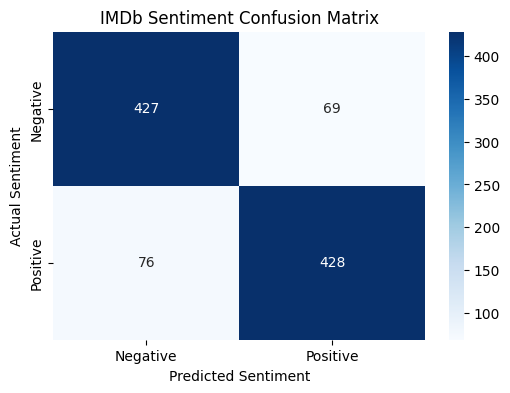

In [15]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the uploaded IMDb CSV file
# Ensure your uploaded file name matches 'IMDB Dataset.csv' or adjust the path below
file_path = '/content/sample_data/IMDB Dataset.csv'
df = pd.read_csv(file_path)

# 2. Map sentiment labels ('positive' / 'negative') to binary integers (1 / 0)
if df['sentiment'].dtype == object:
    df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Optional: Sample 5,000 reviews for faster lemmatization during testing in Colab
# (Remove .sample(5000) if you want to train on the full 50,000 dataset)
df_sample = df.sample(n=5000, random_state=42).reset_index(drop=True)

print(f"Dataset loaded successfully! Total records used: {len(df_sample)}")

# 3. Apply your custom NLP Preprocessor (Preserving negations & POS lemmatization)
print("\nApplying text preprocessing (Tokenization, Negation Retention, Lemmatization)...")
processor = TextPreprocessor()
df_sample['cleaned_review'] = df_sample['review'].apply(processor.clean_text)

# 4. Train-Test Split (80% Train, 20% Test)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df_sample['cleaned_review'],
    df_sample['sentiment'],
    test_size=0.20,
    random_state=42,
    stratify=df_sample['sentiment']
)

# 5. TF-IDF Vectorization with N-Grams (Unigrams + Bigrams) & CSR Sparse Matrix
print("Vectorizing text using TF-IDF (N-Gram range 1-2)...")
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

# 6. Model Training using Multinomial Naive Bayes (Laplace Smoothing alpha=1.0)
print("Training Multinomial Naive Bayes Model...")
model = MultinomialNB(alpha=1.0)
model.fit(X_train_tfidf, y_train)

# 7. Model Evaluation & Accuracy Check
y_pred = model.predict(X_test_tfidf)
acc = accuracy_score(y_test, y_pred)

print("\n" + "="*40)
print(f" MODEL ACCURACY: {acc * 100:.2f}%")
print("="*40 + "\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# 8. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('IMDb Sentiment Confusion Matrix')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()



---



---



